# Imports

In [56]:
from io import BytesIO
from pathlib import Path
from zipfile import ZipFile

import matplotlib.pyplot as plt
import pandas as pd

from tqdm.auto import tqdm

# Prameters

In [57]:
folder_path = "/home/amitner/Backbone-Graph/data/Labeled_Datasets/Venezuela"

# Combine Parquet Parts

In [58]:
def combine_parquet_parts(
    folder_path: str | Path,
    base_name: str | None = None,
    pattern: str = "*.parquet",
    output_compression: str = "gzip",
) -> tuple[pd.DataFrame, Path]:
    """Combine parquet parts stored in ZIP archives.

    ZIP archives are read directly and do not need to be extracted first.
    Members whose names contain ``part_all`` are ignored.

    Args:
        folder_path: Country folder containing ZIP archives.
        base_name: Output filename prefix. Defaults to the folder name.
        pattern: Glob pattern used to find parquet files.
        output_compression: Compression used for the combined parquet file.

    Returns:
        A tuple containing the combined DataFrame and its saved path.

    Raises:
        ValueError: If no parquet parts are found.
    """
    folder_path = Path(folder_path)
    base_name = base_name or folder_path.name
    zip_files = sorted(folder_path.glob("*.zip"))
    print(f"Found {len(zip_files):,} ZIP archives in {folder_path}:")

    dataframes = []

    for zip_path in zip_files:
        print(f"Processing ZIP archive: {zip_path.name}")
        with ZipFile(zip_path) as archive:
            member_names = sorted(
                name
                for name in archive.namelist()
                if Path(name).match(pattern) and "part_all" not in Path(name).name
            )
            print(f"Found {len(member_names):,} parquet parts in {zip_path.name}:")

            for member_name in tqdm(member_names, desc="Processing members"):
                parquet_bytes = BytesIO(archive.read(member_name))
                dataframes.append(pd.read_parquet(parquet_bytes))

    if not dataframes:
        raise ValueError(f"No parquet parts found in {folder_path}")

    print(f"Found {len(dataframes):,} parquet parts:")

    print(f"Combining {len(dataframes):,} DataFrames...")
    combined_df = pd.concat(dataframes, ignore_index=True)
    output_path = folder_path / f"{base_name}_part_all.gzip.parquet"
    combined_df.to_parquet(output_path, compression=output_compression, index=False)

    print(f"Combined shape: {combined_df.shape[0]:,} rows x {combined_df.shape[1]:,} columns")

    memory_bytes = combined_df.memory_usage(deep=True).sum()
    if memory_bytes >= 1024**3:
        print(f"combined_df memory usage: {memory_bytes / 1024**3:.2f} GB")
    else:
        print(f"combined_df memory usage: {memory_bytes / 1024**2:.2f} MB")

    print(f"Saved to: {output_path}")

    return combined_df, output_path

In [59]:
combined_df, combined_path = combine_parquet_parts(folder_path)

Found 2 ZIP archives in /home/amitner/Backbone-Graph/data/Labeled_Datasets/Venezuela:
Processing ZIP archive: Venezuela_1.zip
Found 25 parquet parts in Venezuela_1.zip:


Processing members:   0%|          | 0/25 [00:00<?, ?it/s]

Processing ZIP archive: Venezuela_2.zip
Found 15 parquet parts in Venezuela_2.zip:


Processing members:   0%|          | 0/15 [00:00<?, ?it/s]

Found 40 parquet parts:
Combining 40 DataFrames...
Combined shape: 1,972,732 rows x 19 columns
combined_df memory usage: 1.81 GB
Saved to: /home/amitner/Backbone-Graph/data/Labeled_Datasets/Venezuela/Venezuela_part_all.gzip.parquet


# Statistics and Visualization

In [60]:
def create_statistics_and_visualization(
    df: pd.DataFrame,
    folder_path: str | Path,
) -> pd.DataFrame:
    """Calculate country statistics and save a summary visualization.

    Args:
        df: Combined posts with ``accountid`` and ``is_control`` columns.
        folder_path: Country folder containing the source ZIP archives.

    Returns:
        One-row DataFrame containing account, post, and source-file counts.
    """
    folder_path = Path(folder_path)
    zip_files = sorted(folder_path.glob("*.zip"))

    part_count = 0
    for zip_path in zip_files:
        with ZipFile(zip_path) as archive:
            part_count += sum(
                Path(name).suffix == ".parquet"
                and "part_all" not in Path(name).name
                for name in archive.namelist()
            )

    control_values = df["is_control"].replace(
        {
            True: True,
            False: False,
            1: True,
            0: False,
            "True": True,
            "true": True,
            "False": False,
            "false": False,
        }
    )

    control_mask = control_values.fillna(False).astype(bool)

    io_posts = int((~control_mask).sum())
    control_posts = int(control_mask.sum())

    statistics_df = pd.DataFrame(
        [
            {
                "Country": folder_path.name,
                "Campaign files": ", ".join(path.stem for path in zip_files),
                "50k-post parts": part_count,
                "IO accounts": df.loc[
                    ~control_mask, "accountid"
                ].nunique(),
                "Control accounts": df.loc[
                    control_mask, "accountid"
                ].nunique(),
                "IO posts": io_posts,
                "Control posts": control_posts,
                "Total posts": len(df),
            }
        ]
    )

    statistics_path = folder_path / f"{folder_path.name}_statistics.csv"
    statistics_df.to_csv(statistics_path, index=False)

    display(statistics_df.style.format(thousands=","))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    colors = ["#d95f02", "#1b9e77"]

    account_values = [
        statistics_df.at[0, "IO accounts"],
        statistics_df.at[0, "Control accounts"],
    ]
    post_values = [io_posts, control_posts]

    for axis, values, title in zip(
        axes,
        [account_values, post_values],
        ["Unique accounts", "Posts"],
    ):
        bars = axis.bar(["IO", "Control"], values, color=colors)

        axis.bar_label(
            bars,
            labels=[f"{value:,}" for value in values],
            padding=3,
            fontsize=12,
        )

        axis.set_title(title, fontsize=16)
        axis.tick_params(axis="both", labelsize=13)
        axis.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda value, _: f"{value:,.0f}")
        )
        axis.margins(y=0.15)

    fig.suptitle(
        f"{folder_path.name} dataset summary",
        fontsize=19,
    )
    fig.tight_layout()

    figure_path = folder_path / f"{folder_path.name}_statistics.png"
    fig.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Saved statistics to: {statistics_path}")
    print(f"Saved visualization to: {figure_path}")

    return statistics_df

,Country,Campaign files,50k-post parts,IO accounts,Control accounts,IO posts,Control posts,Total posts
0,Venezuela,"Venezuela_1, Venezuela_2",40,611,"9,745","1,554,433","418,299","1,972,732"


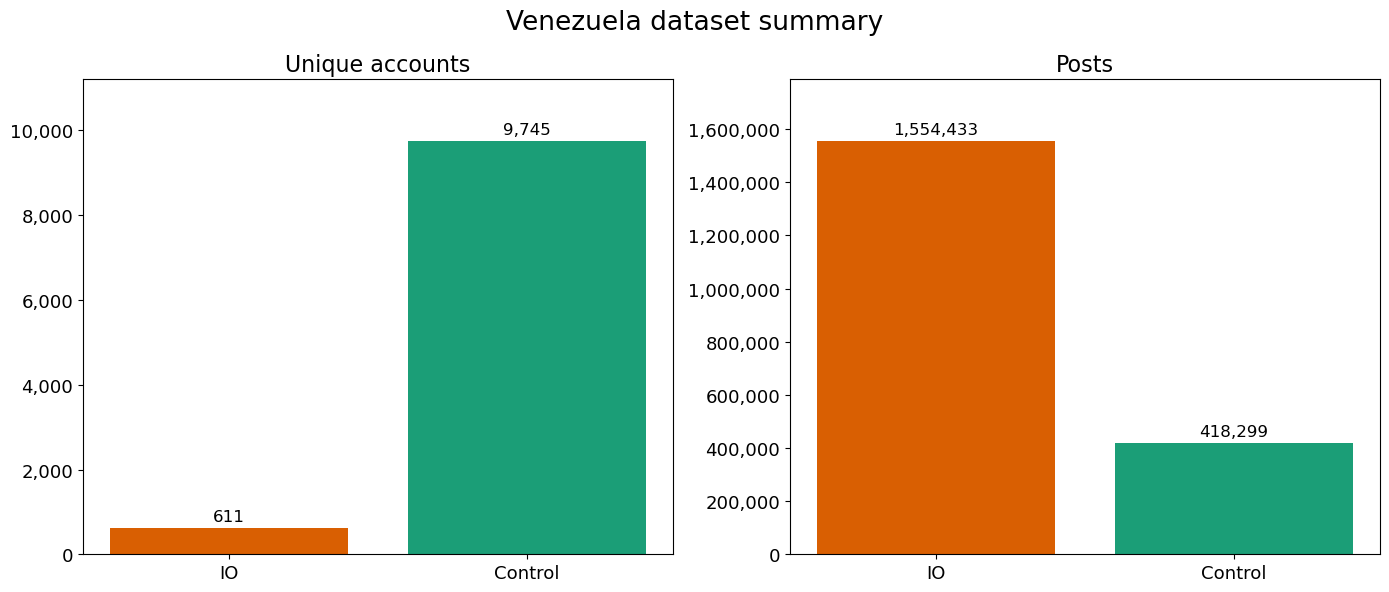

Saved statistics to: /home/amitner/Backbone-Graph/data/Labeled_Datasets/Venezuela/Venezuela_statistics.csv
Saved visualization to: /home/amitner/Backbone-Graph/data/Labeled_Datasets/Venezuela/Venezuela_statistics.png


In [61]:
statistics_df = create_statistics_and_visualization(combined_df, folder_path)

# Posting Over Time

In [62]:
def plot_posting_over_time(
    combined_df: pd.DataFrame,
    time_window: str,
    folder_path: str | Path | None = None,
    activity_share: float = 0.70,
) -> pd.DataFrame:
    """Plot full and central-activity post counts over time.

    Args:
        combined_df: Posts containing ``post_time`` and ``is_control`` columns.
        time_window: Pandas resampling frequency, such as ``D``, ``W``, or ``ME``.
        folder_path: Optional folder in which to save the plot.
        activity_share: Share of posts to include in the shortest focused period.

    Returns:
        DataFrame containing the three posting counts per time window.

    Raises:
        ValueError: If timestamps are invalid or activity_share is out of range.
    """
    posting_df = combined_df[["post_time", "is_control"]].copy()
    posting_df["post_time"] = pd.to_datetime(
        posting_df["post_time"], errors="coerce"
    )
    posting_df = posting_df.dropna(subset=["post_time"])
    if posting_df.empty:
        raise ValueError("No valid values were found in the post_time column")
    if not 0 < activity_share <= 1:
        raise ValueError("activity_share must be greater than 0 and at most 1")

    posting_df["is_control"] = (
        posting_df["is_control"].fillna(False).astype(bool)
    )
    posting_df["IO posting"] = (~posting_df["is_control"]).astype(int)
    posting_df["Legitimate posting"] = posting_df["is_control"].astype(int)
    posting_df["Total posting"] = 1

    posting_counts = (
        posting_df.set_index("post_time")[
            ["IO posting", "Legitimate posting", "Total posting"]
        ]
        .resample(time_window)
        .sum()
    )

    window_names = {
        "D": "Day",
        "W": "Week",
        "ME": "Month",
        "M": "Month",
        "QE": "Quarter",
        "Q": "Quarter",
        "YE": "Year",
        "Y": "Year",
    }
    window_code = time_window.upper().split("-")[0]
    window_label = window_names.get(window_code, time_window)

    fig, axis = plt.subplots(figsize=(18, 9))
    colors = {
        "IO posting": "#d95f02",
        "Legitimate posting": "#1b9e77",
        "Total posting": "#3b528b",
    }
    plot_order = ["Total posting", "IO posting", "Legitimate posting"]
    for column in plot_order:
        axis.plot(
            posting_counts.index,
            posting_counts[column],
            label=column,
            color=colors[column],
            linewidth=5 if column == "Total posting" else 2.5,
            alpha=0.85 if column == "Total posting" else 1.0,
            zorder=1 if column == "Total posting" else 2,
        )

    axis.set_title(f"Posting Over Time by {window_label}", fontsize=30, pad=18)
    axis.set_xlabel("Time", fontsize=26, labelpad=12)
    axis.set_ylabel("Number of Posts", fontsize=26, labelpad=12)
    axis.tick_params(axis="both", labelsize=16)
    axis.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:,.0f}"))
    axis.legend(fontsize=17)
    axis.grid(alpha=0.25)
    fig.tight_layout()

    if folder_path is not None:
        folder_path = Path(folder_path)
        safe_window = time_window.replace("/", "-")
        figure_path = folder_path / f"{folder_path.name}_posting_over_time_{safe_window}.png"
        fig.savefig(figure_path, dpi=300, bbox_inches="tight")
        print(f"Saved posting-over-time visualization to: {figure_path}")

    plt.show()

    total_posts = posting_counts["Total posting"].sum()
    target_posts = total_posts * activity_share
    activity_values = posting_counts["Total posting"].to_numpy()
    lower_position = 0
    best_lower_position = 0
    best_upper_position = len(activity_values) - 1
    best_window_length = len(activity_values)
    current_posts = 0

    for upper_position, post_count in enumerate(activity_values):
        current_posts += post_count
        while (
            lower_position < upper_position
            and current_posts - activity_values[lower_position] >= target_posts
        ):
            current_posts -= activity_values[lower_position]
            lower_position += 1

        window_length = upper_position - lower_position + 1
        if current_posts >= target_posts and window_length < best_window_length:
            best_lower_position = lower_position
            best_upper_position = upper_position
            best_window_length = window_length

    lower_position = best_lower_position
    upper_position = best_upper_position
    focused_counts = posting_counts.iloc[lower_position : upper_position + 1]
    captured_share = focused_counts["Total posting"].sum() / total_posts
    activity_percent = round(activity_share * 100)

    focused_fig, focused_axis = plt.subplots(figsize=(18, 9))
    for column in plot_order:
        focused_axis.plot(
            focused_counts.index,
            focused_counts[column],
            label=column,
            color=colors[column],
            linewidth=5 if column == "Total posting" else 2.5,
            alpha=0.85 if column == "Total posting" else 1.0,
            zorder=1 if column == "Total posting" else 2,
        )

    focused_axis.set_title(
        f"Posting Over Time by {window_label}: Main {activity_percent}% of Activity",
        fontsize=30,
        pad=18,
    )
    focused_axis.set_xlabel("Time", fontsize=26, labelpad=12)
    focused_axis.set_ylabel("Number of Posts", fontsize=26, labelpad=12)
    focused_axis.tick_params(axis="both", labelsize=16)
    focused_axis.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda value, _: f"{value:,.0f}")
    )
    focused_axis.legend(fontsize=17)
    focused_axis.grid(alpha=0.25)
    focused_fig.tight_layout()

    print(
        f"Shortest period capturing {captured_share:.1%} of activity: "
        f"{focused_counts.index.min():%Y-%m-%d} to "
        f"{focused_counts.index.max():%Y-%m-%d}"
    )
    if folder_path is not None:
        focused_figure_path = (
            folder_path
            / f"{folder_path.name}_posting_over_time_{safe_window}_main_{activity_percent}_percent.png"
        )
        focused_fig.savefig(focused_figure_path, dpi=300, bbox_inches="tight")
        print(f"Saved focused visualization to: {focused_figure_path}")

    plt.show()
    return posting_counts

Saved posting-over-time visualization to: /home/amitner/Backbone-Graph/data/Labeled_Datasets/Venezuela/Venezuela_posting_over_time_W.png


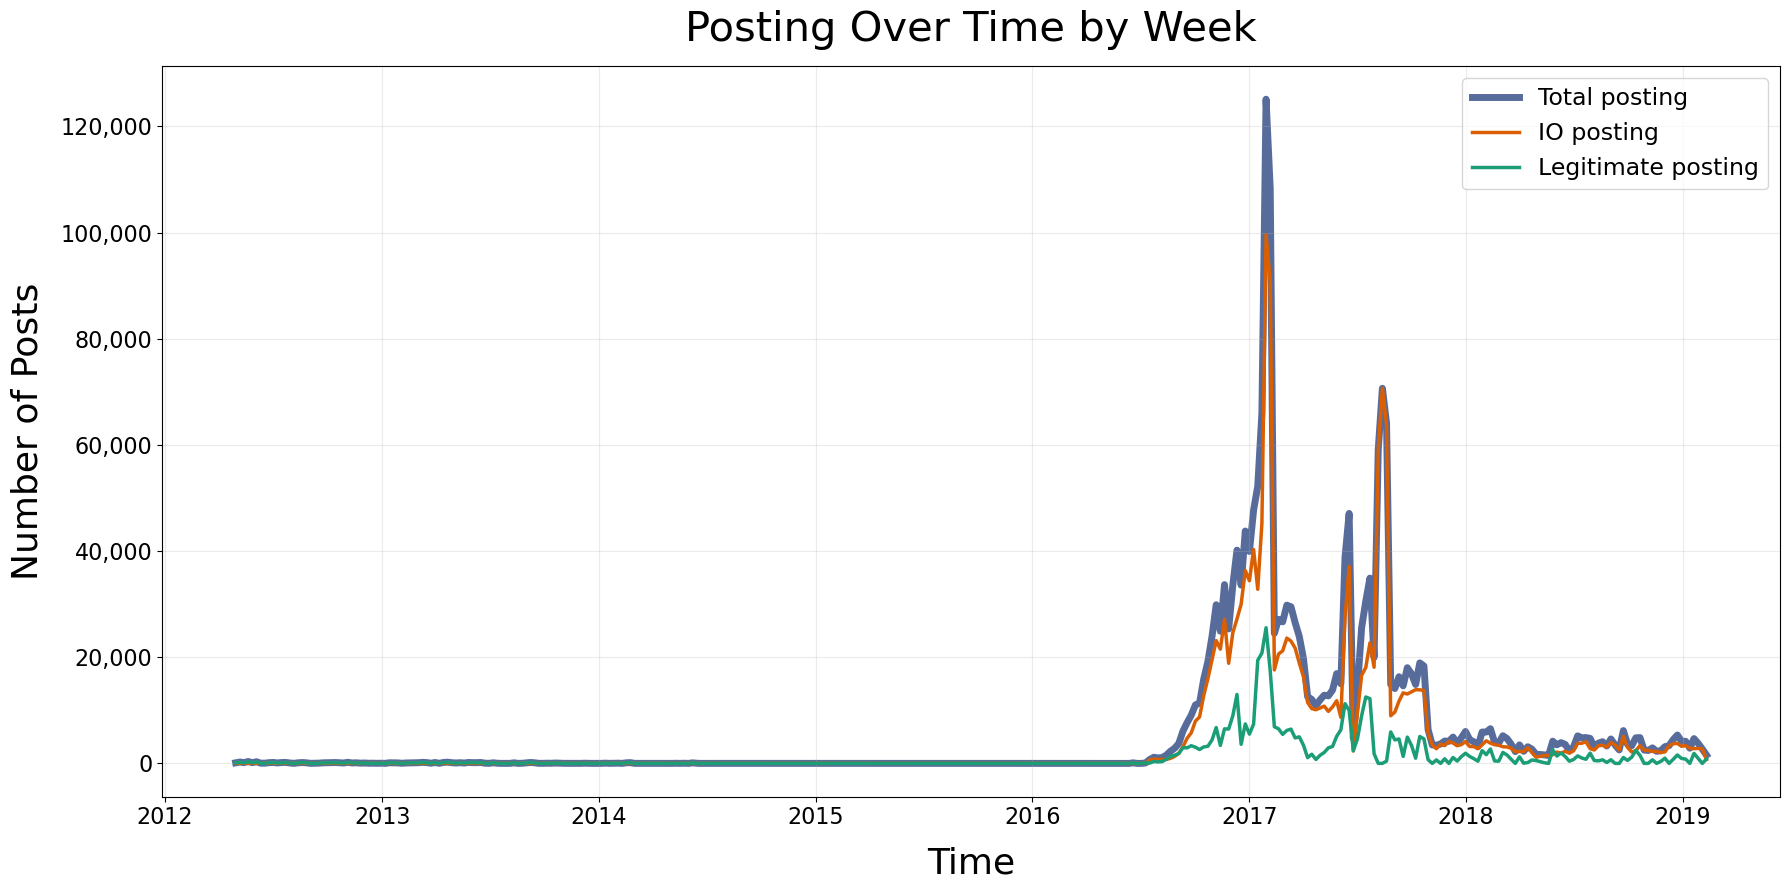

Shortest period capturing 70.3% of activity: 2016-11-20 to 2017-08-20
Saved focused visualization to: /home/amitner/Backbone-Graph/data/Labeled_Datasets/Venezuela/Venezuela_posting_over_time_W_main_70_percent.png


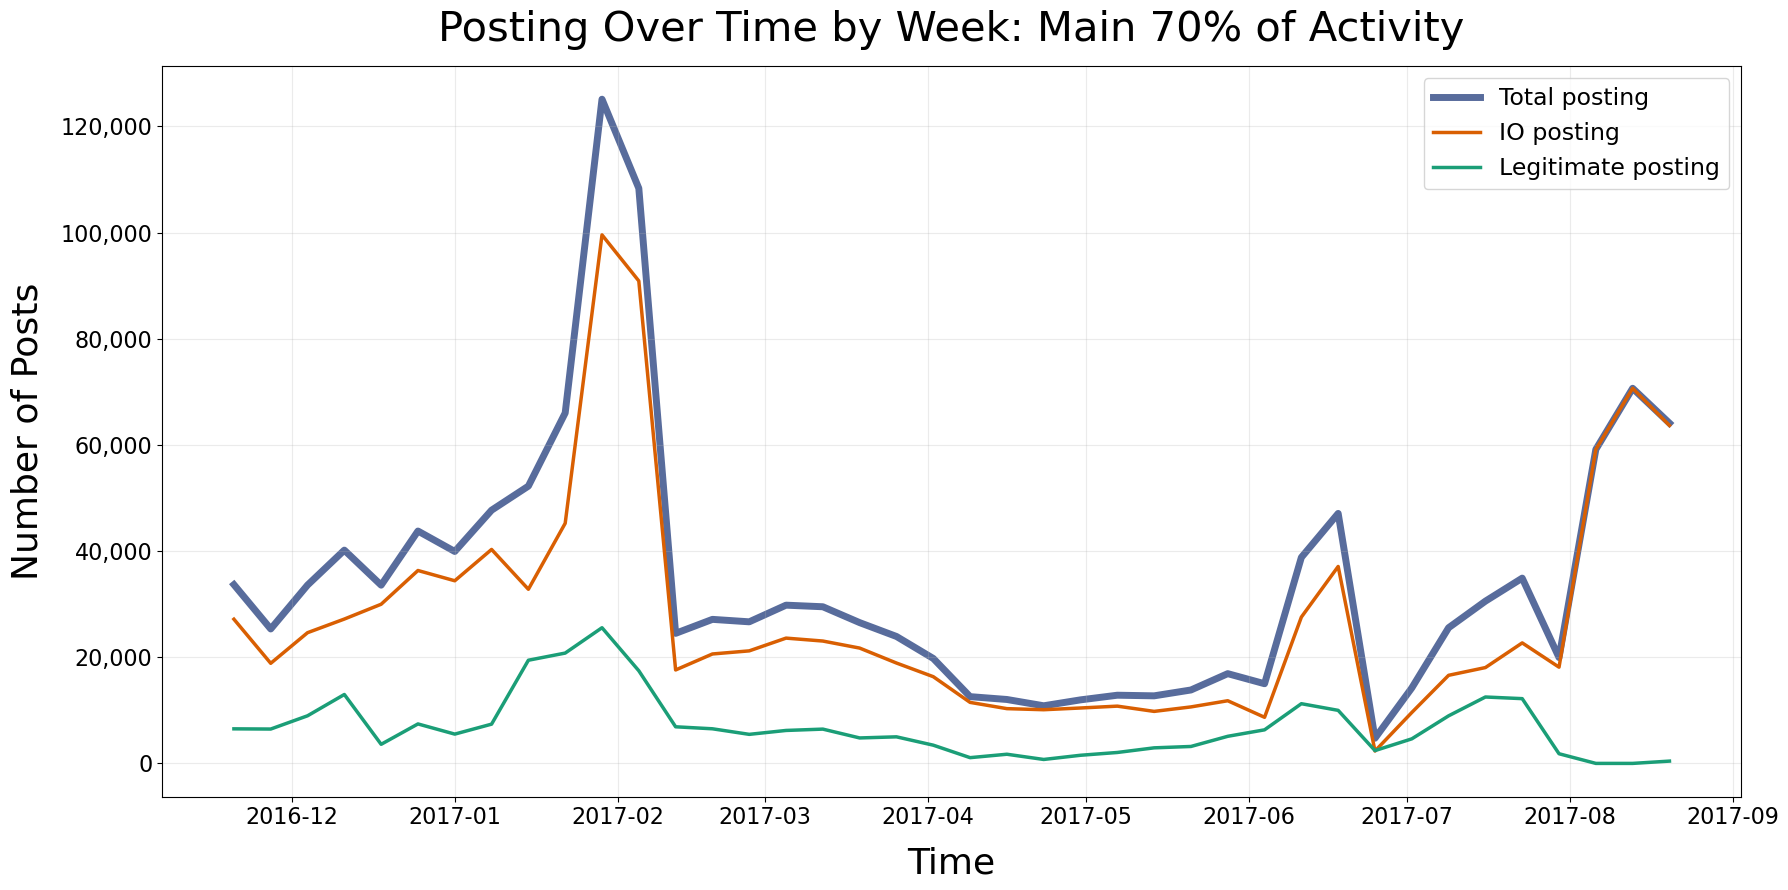

In [63]:
posting_counts = plot_posting_over_time(
    combined_df, time_window="W", folder_path=folder_path
)